In [1]:
import obs_data_functions as odf
from generic_decision_tree import decision_tree
import matplotlib.pyplot as plt
import numpy as np

## 1. Load Stokes I/Q/U FITS

(900.0, 1150.0)

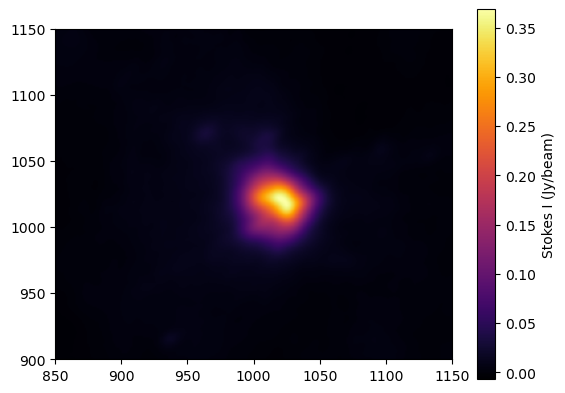

In [2]:
ifile = 'G31/G31_41-StokesI.fits'
qfile = 'G31/G31_41-StokesQ.fits'
ufile = 'G31/G31_41-StokesU.fits'
I, Q, U, hdr = odf.load_casa_stokes(ifile, qfile, ufile) # works for ALMA, VLA, and other CASA-produced FITS files

plt.imshow(I, origin='lower', cmap='inferno')
plt.colorbar(label='Stokes I (Jy/beam)')
plt.xlim(850,1150)
plt.ylim(900,1150)

(900.0, 1150.0)

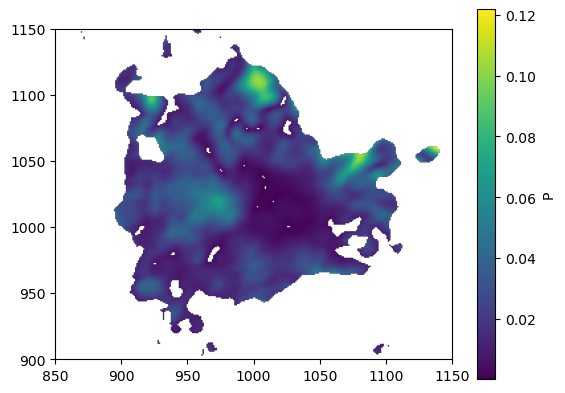

In [3]:
# 2. Noise-debias -> P (fraction), PHI (radians)
P, PHI, sP, sPHI = odf.compute_P_PHI(I, Q, U, sigma_I=None, sigma_Q=None, sigma_U=None, 
                                     i_snr=5.0, p_snr=3.0, debias=True, 
                                     angle_unit="radians", rms_region=(slice(0, 100), slice(0, 100)))


plt.imshow(P, origin='lower', cmap='viridis')
plt.colorbar(label='P')
plt.xlim(850,1150)
plt.ylim(900,1150)

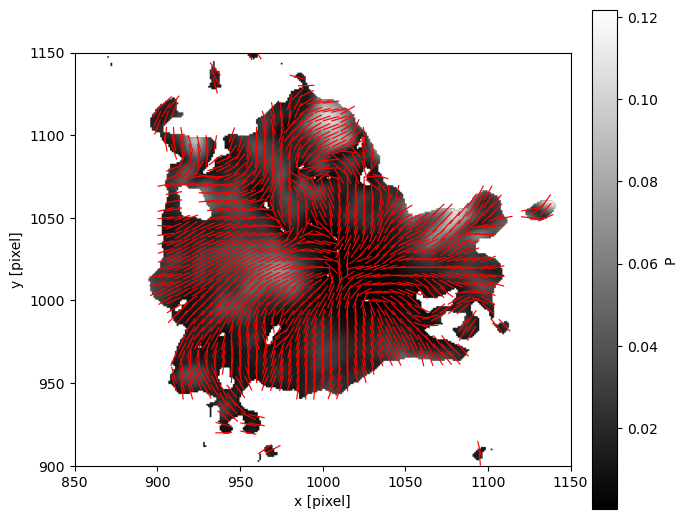

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
cmap='gray'
step = 5

im = ax.imshow(P, origin="lower", cmap=cmap)
plt.colorbar(im, ax=ax, label="P",fraction=0.046, pad=0.04 )

ny, nx = P.shape
y, x = np.mgrid[0:ny:step, 0:nx:step]
phi_sub = PHI[0:ny:step, 0:nx:step]

U = np.cos(phi_sub)
V = np.sin(phi_sub)
valid = np.isfinite(U) & np.isfinite(V)

ax.quiver(
    x[valid], y[valid], U[valid], V[valid],
    angles="xy", pivot="middle",
    headwidth=0, headlength=0, headaxislength=0,  # headless -> orientation, not direction
    scale=0.1, scale_units="xy",
    color="red", linewidth=0.8)

ax.set_xlim(850,1150)
ax.set_ylim(900,1150)
ax.set_xlabel("x [pixel]")
ax.set_ylabel("y [pixel]")
ax.set_aspect("equal")
plt.savefig("G31_PHI_map.png", dpi=300, bbox_inches="tight")

(900.0, 1150.0)

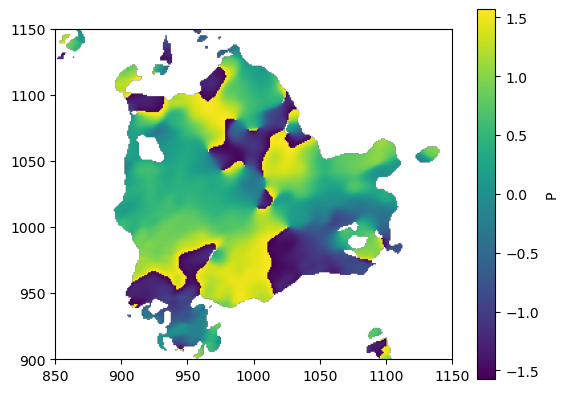

In [4]:
plt.imshow(PHI, origin='lower', cmap='viridis')
plt.colorbar(label='P')
plt.xlim(850,1150)
plt.ylim(900,1150)

In [6]:
# 3. Remove grain-alignment-efficiency trend (p-I power law)
P_corrected, fit_info = odf.debias_grain_alignment(P, I)

print(f"alpha={fit_info['alpha']:.2f}, r2={fit_info['r2']:.2f}, "
      f"frac_outside_fit_range={fit_info['frac_outside_fit_range']:.1%}, "
      f"frac_above_1_preclip={fit_info['frac_above_1_preclip']:.1%}")

alpha=0.33, r2=0.21, frac_outside_fit_range=98.9%, frac_above_1_preclip=46.7%


(900.0, 1150.0)

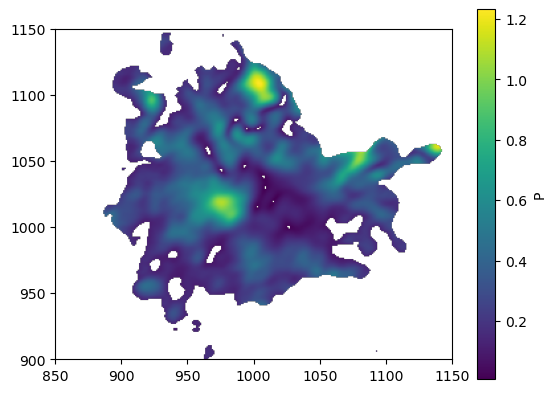

In [7]:
plt.imshow(P_corrected, origin='lower', cmap='viridis')
plt.colorbar(label='P')
plt.xlim(850,1150)
plt.ylim(900,1150)

In [ ]:
# 4. Classify geometry
geometry = decision_tree(P_corrected, PHI, M_PHI=your_paper_value)